In [37]:
import sys
print(sys.executable)

/Users/somasricharan/Desktop/EndToEnd_ML_Project/venv/bin/python


In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [39]:
df = pd.read_csv('Data/study.csv')

In [40]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [41]:
df.shape

(1000, 8)

## DATASET INFORMATION

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

Checking The Missing Values

In [42]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [43]:
df.duplicated().sum()

np.int64(0)

In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [45]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [46]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

In [47]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [48]:
print("Categories in 'gender' variable:     ",end=" " )
print(df['gender'].unique())
print("-----------------------------------------------------------")
print("Categories in 'race/ethnicity' variable:  ",end=" ")
print(df['race/ethnicity'].unique())
print("-----------------------------------------------------------")
print("Categories in'parental level of education' variable:",end=" " )
print(df['parental level of education'].unique())
print("-----------------------------------------------------------")
print("Categories in 'lunch' variable:     ",end=" " )
print(df['lunch'].unique())
print("-----------------------------------------------------------")
print("Categories in 'test preparation course' variable:     ",end=" " )
print(df['test preparation course'].unique())

Categories in 'gender' variable:      <StringArray>
['female', 'male']
Length: 2, dtype: str
-----------------------------------------------------------
Categories in 'race/ethnicity' variable:   <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
-----------------------------------------------------------
Categories in'parental level of education' variable: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
-----------------------------------------------------------
Categories in 'lunch' variable:      <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
-----------------------------------------------------------
Categories in 'test preparation course' variable:      <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [49]:
df.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

In [53]:
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'str']

categorical_features = [feature for feature in df.columns if df[feature].dtype == 'str']

print("We have {} numerical features : {}".format(len(numerical_features), numerical_features))

print("\nWe have {} categorical features : {}".format(len(categorical_features), categorical_features))

We have 3 numerical features : ['math score', 'reading score', 'writing score']

We have 5 categorical features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [54]:
df.head(2)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


## Feature Engineering

In [56]:
import numpy as np


# 1. Average Score
df['average_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3


# 2. Total Score
df['total_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
)


# 3. Performance Category
def classify_performance(score):
    
    if score >= 85:
        return 'Excellent'
    
    elif score >= 70:
        return 'Good'
    
    elif score >= 50:
        return 'Average'
    
    else:
        return 'Poor'


df['performance_level'] = df['average_score'].apply(classify_performance)



# 4. Academic Consistency Score
# Measures variance between subject scores
# Lower std -- more balanced student
df['score_consistency'] = df[
    ['math score', 'reading score', 'writing score']
].std(axis=1)


# 5. Study Effort Index
prep_map = {
    'completed': 1,
    'none': 0
}

df['prep_status'] = df['test preparation course'].map(prep_map)

df['study_effort_index'] = (
    (0.7 * df['average_score']) +
    (0.3 * df['prep_status'] * 100)
)



# 6. Parental Education Score
education_map = {
    'some high school': 1,
    'high school': 2,
    'some college': 3,
    "associate's degree": 4,
    "bachelor's degree": 5,
    "master's degree": 6
}

df['parental_education_score'] = (
    df['parental level of education']
    .map(education_map)
)



# 7. Nutrition Index
lunch_map = {
    'free/reduced': 0,
    'standard': 1
}

df['nutrition_index'] = df['lunch'].map(lunch_map)



# 8. Reading-Writing Alignment
df['language_alignment'] = abs(
    df['reading score'] - df['writing score']
)



# 9. STEM Strength Indicator
# Math dominance over language subjects

df['stem_strength'] = (
    df['math score'] -
    (
        (df['reading score'] + df['writing score']) / 2
    )
)



# 10. High Performer Flag
df['is_high_performer'] = np.where(
    df['average_score'] >= 75,
    1,
    0
)



df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,total_score,performance_level,score_consistency,prep_status,study_effort_index,parental_education_score,nutrition_index,language_alignment,stem_strength,is_high_performer
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667,218,Good,1.154701,0,50.866667,5,1,2,-1.0,0
1,female,group C,some college,standard,completed,69,90,88,82.333333,247,Good,11.590226,1,87.633333,3,1,2,-20.0,1
2,female,group B,master's degree,standard,none,90,95,93,92.666667,278,Excellent,2.516611,0,64.866667,6,1,2,-4.0,1
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333,148,Poor,6.806859,0,34.533333,4,0,13,-3.5,0
4,male,group C,some college,standard,none,76,78,75,76.333333,229,Good,1.527525,0,53.433333,3,1,3,-0.5,1


In [57]:
subjects = ['math score', 'reading score', 'writing score']

print("Students scoring 100 marks\n")

for subject in subjects:
    
    count = df[df[subject] == 100][subject].count()
    
    print(f"{subject.upper()} : {count}")



print("\nStudents scoring less than 20 marks\n")

for subject in subjects:
    
    count = df[df[subject] <= 20][subject].count()
    
    print(f"{subject.upper()} : {count}")

Students scoring 100 marks

MATH SCORE : 7
READING SCORE : 17
WRITING SCORE : 14

Students scoring less than 20 marks

MATH SCORE : 4
READING SCORE : 1
WRITING SCORE : 3


## EDA

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

Outlier Detection

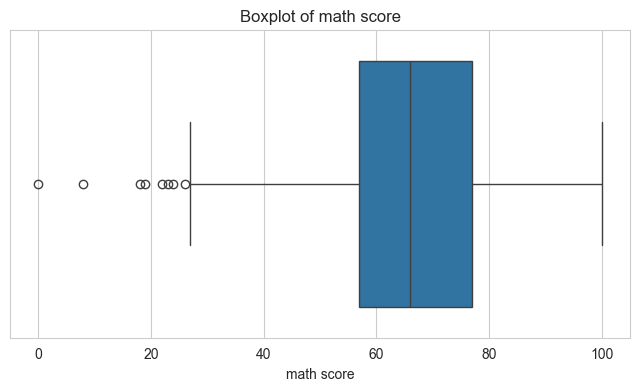

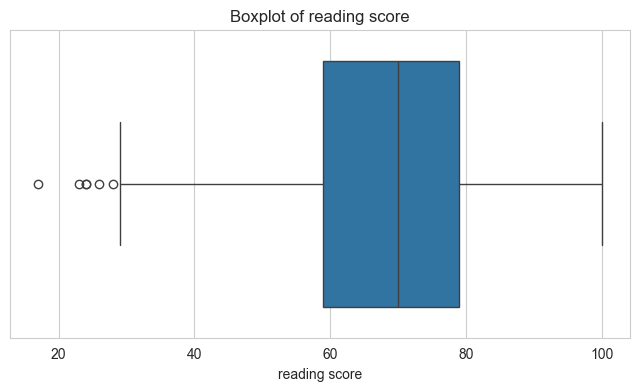

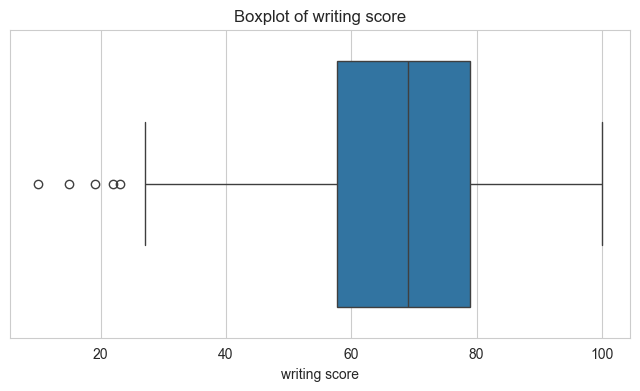

In [59]:
for col in numerical_features:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

1. Boxplot — Math Score
Insight
Mathematics contains several lower-end outliers.
Most students scored between 55–78.
Few students performed extremely poorly (<30).
Median score is around 66–68.
Business Interpretation
Mathematics appears to be the most challenging subject, with higher variability and more low-performing students compared to language-based subjects.
2. Boxplot — Reading Score
Insight
Reading scores are more concentrated and stable.
Fewer extreme outliers exist.
Majority of students scored between 60–80.
Median performance is higher than Mathematics.
Business Interpretation
Students generally demonstrate stronger reading comprehension skills compared to quantitative skills.
3. Boxplot — Writing Score
Insight
Writing scores follow a similar trend to Reading.
Few low-score outliers exist.
Most students perform consistently in writing.
Business Interpretation
Writing ability is relatively stable across students and highly aligned with reading performance.

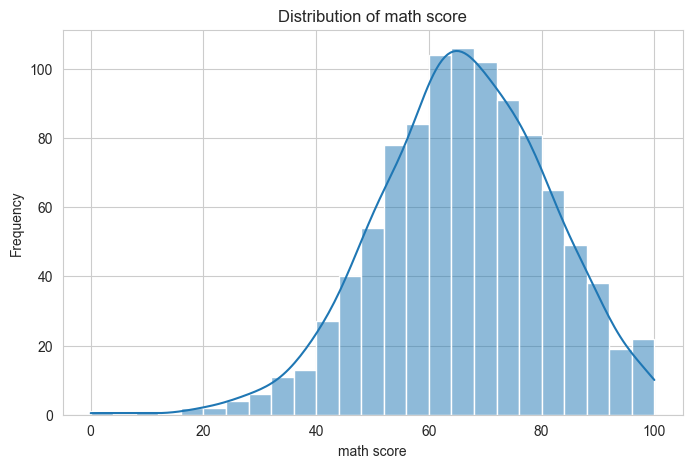

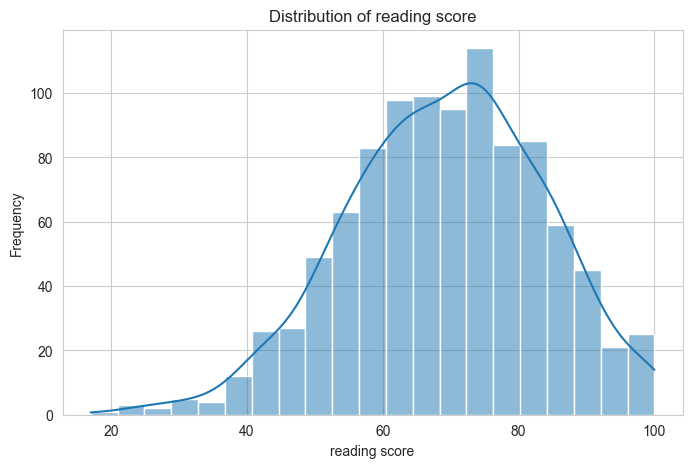

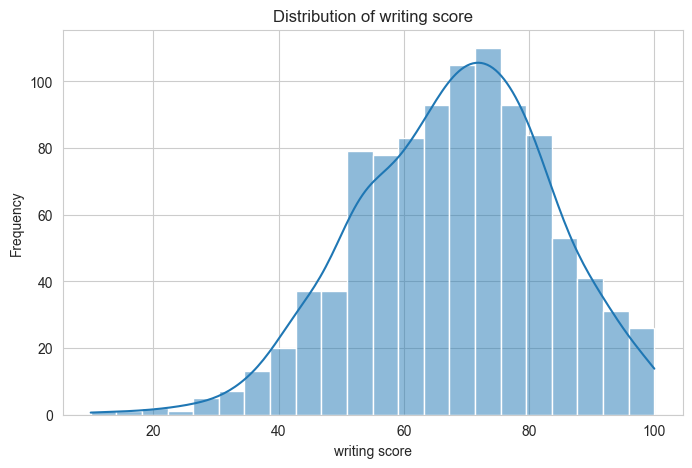

In [72]:
for col in numerical_features:
    
    plt.figure(figsize=(8,5))
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f"Distribution of {col}")
    
    plt.xlabel(col)
    
    plt.ylabel("Frequency")
    
    plt.show()

4. Distribution — Math Score
Insight
Distribution is slightly negatively skewed.
Majority of students scored around 60–75.
Low-score tail exists due to struggling students.
Interpretation
The dataset indicates that average-to-good mathematical performance is common, while very poor performance occurs only in a smaller subset of students.
5. Distribution — Reading Score
Insight
Distribution is closer to normal compared to Mathematics.
Peak occurs around 70–75.
Reading scores show lower variance.
Interpretation
Reading performance is relatively balanced and indicates consistent literacy skills across students.
6. Distribution — Writing Score
Insight
Writing scores approximately follow a bell-shaped distribution.
Most students cluster between 60–80.
Interpretation
Writing performance demonstrates moderate consistency and may be influenced by reading proficiency.

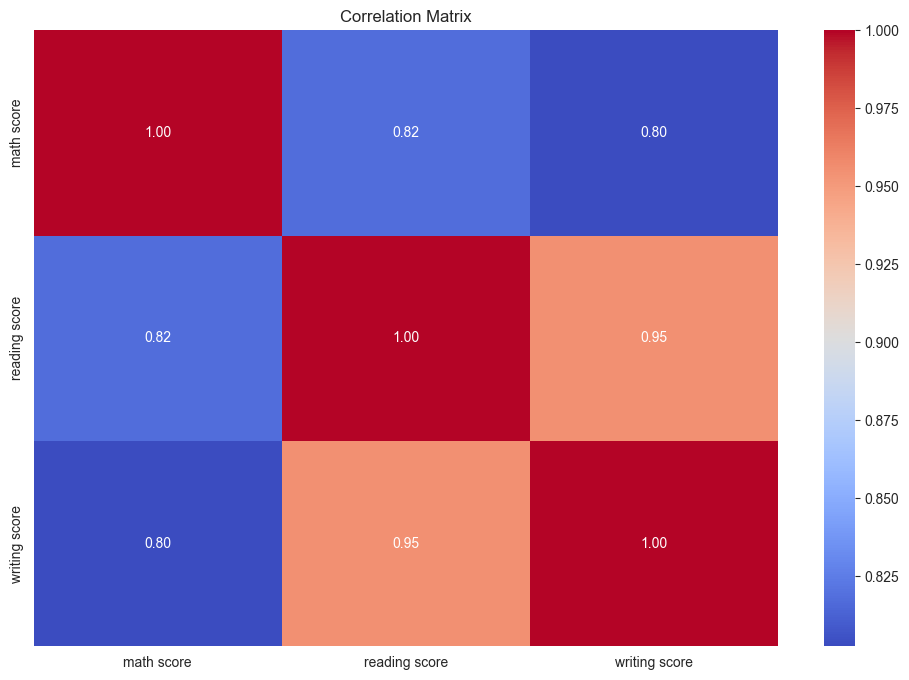

In [63]:
plt.figure(figsize=(12,8))

correlation_matrix = df[numerical_features].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()



Interpretation
Reading and Writing are extremely highly correlated.
Students strong in reading are usually strong in writing.
Mathematics has slightly weaker correlation with language subjects.

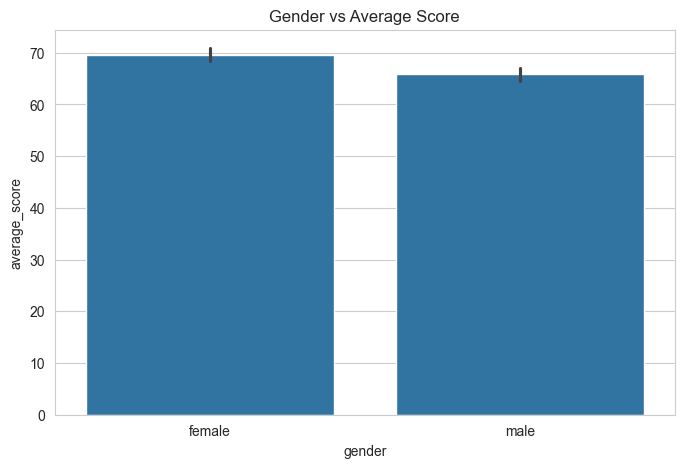

In [65]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='gender',
    y='average_score',
    data=df
)

plt.title("Gender vs Average Score")

plt.show()


Insight
Female students slightly outperform male students overall.
Interpretation
Female students demonstrate marginally better overall academic consistency in this dataset.

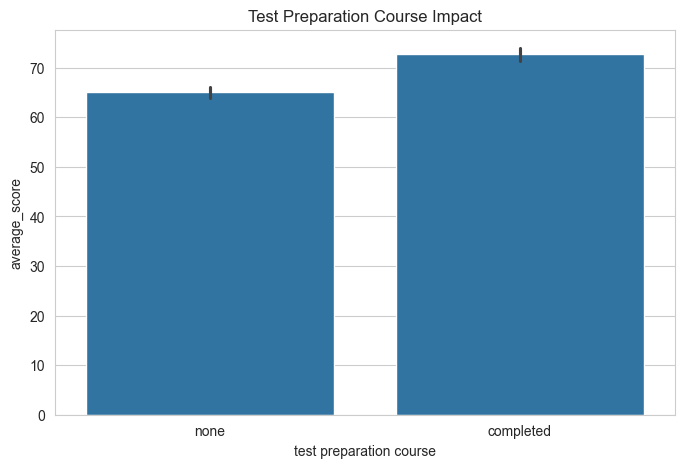

In [66]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='test preparation course',
    y='average_score',
    data=df
)

plt.title("Test Preparation Course Impact")

plt.show()

Insight
Students completing the preparation course achieved significantly higher scores.
Interpretation
Test preparation programs positively impact student academic performance.

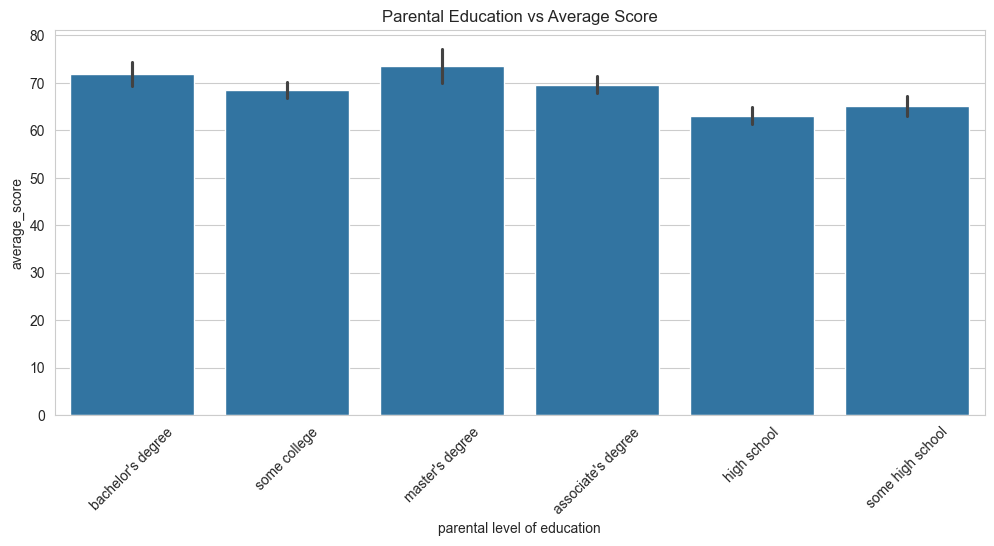

In [67]:
plt.figure(figsize=(12,5))

sns.barplot(
    x='parental level of education',
    y='average_score',
    data=df
)

plt.xticks(rotation=45)

plt.title("Parental Education vs Average Score")

plt.show()

Insight
Students whose parents hold master's or bachelor's degrees tend to score higher.
Students with lower parental education backgrounds show lower average performance.
Interpretation
Higher parental education may contribute to a stronger academic support environment.

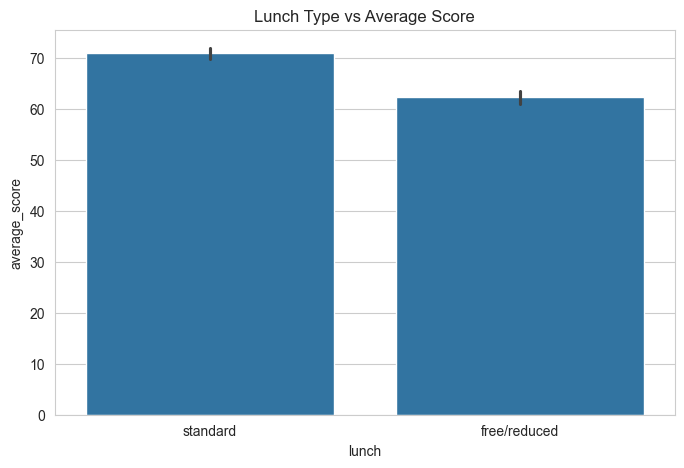

In [68]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='lunch',
    y='average_score',
    data=df
)

plt.title("Lunch Type vs Average Score")

plt.show()

Insight
Students whose parents hold master's or bachelor's degrees tend to score higher.
Students with lower parental education backgrounds show lower average performance.
Interpretation
Higher parental education may contribute to a stronger academic support environment.

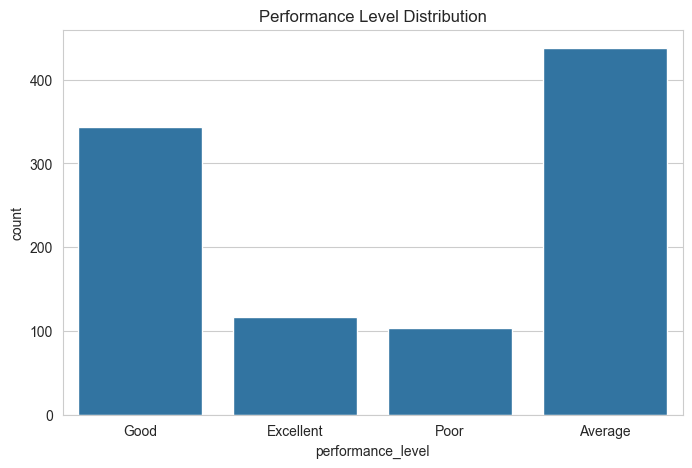

In [69]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='performance_level',
    data=df
)

plt.title("Performance Level Distribution")

plt.show()

Insight
Students receiving standard lunch perform noticeably better.
Interpretation
Nutritional and socioeconomic factors may influence academic performance

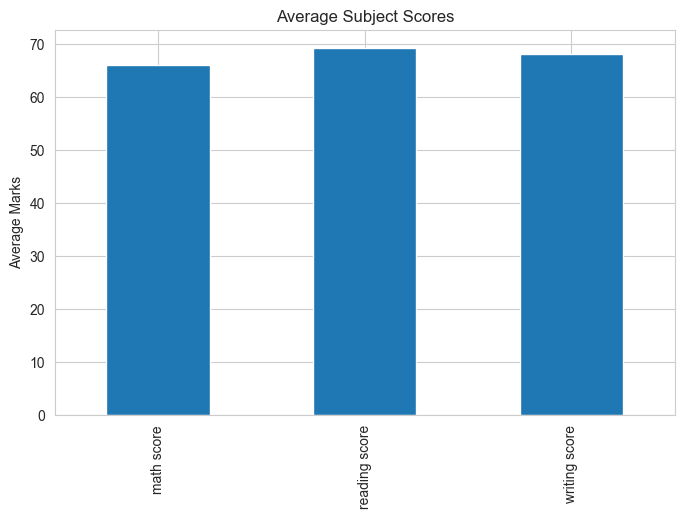

In [70]:
subject_avg = df[
    ['math score', 'reading score', 'writing score']
].mean()

plt.figure(figsize=(8,5))

subject_avg.plot(kind='bar')

plt.title("Average Subject Scores")

plt.ylabel("Average Marks")

plt.show()


Insight
Majority of students fall into Average and Good categories.
Relatively fewer students are classified as Excellent or Poor.
Interpretation
The dataset is moderately balanced, with most students performing within the mid-performance range.

In [75]:
df.to_csv("/Users/somasricharan/Desktop/EndToEnd_ML_Project/notebooks/processed_data/modified_student_performance.csv", index=False)